# Exploratory Data Analysis — UCI Heart Disease (Cleveland)

303 patient records, 13 clinical attributes, binary target (heart disease
presence). Dataset: Janosi, Steinbrunn, Pfisterer, Detrano, "Heart Disease,"
UCI Machine Learning Repository, 1988. https://doi.org/10.24432/C52P4X

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_data, binarize_target

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = load_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Shape and dtypes

In [2]:
print(f"rows={df.shape[0]}, columns={df.shape[1]}")
df.info()

rows=303, columns=14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## Missingness

The dataset's documented missing values live in `ca` (number of major
vessels) and `thal` (thalassemia test result).

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing)

ca      4
thal    2
dtype: int64


## Class balance

`num` is the original 5-class severity target (0 = no disease, 1-4 =
increasing severity). The modeling pipeline collapses this into a binary
disease-present indicator.

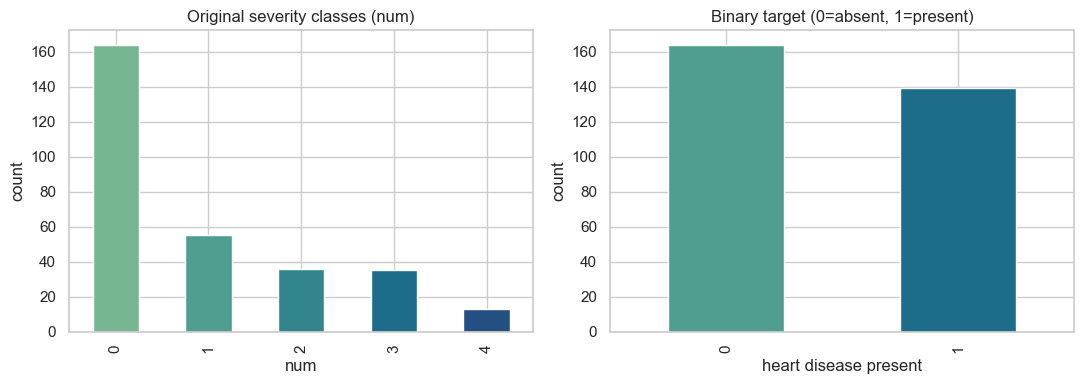

num
0    0.541
1    0.459
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["num"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=sns.color_palette("crest", 5)
)
axes[0].set_title("Original severity classes (num)")
axes[0].set_xlabel("num")
axes[0].set_ylabel("count")

X, y = binarize_target(df)
y.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=sns.color_palette("crest", 2)
)
axes[1].set_title("Binary target (0=absent, 1=present)")
axes[1].set_xlabel("heart disease present")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("class_balance.png", dpi=120)
plt.show()

print(y.value_counts(normalize=True).round(3))

## Correlation heatmap

Numeric attributes plus the binary target.

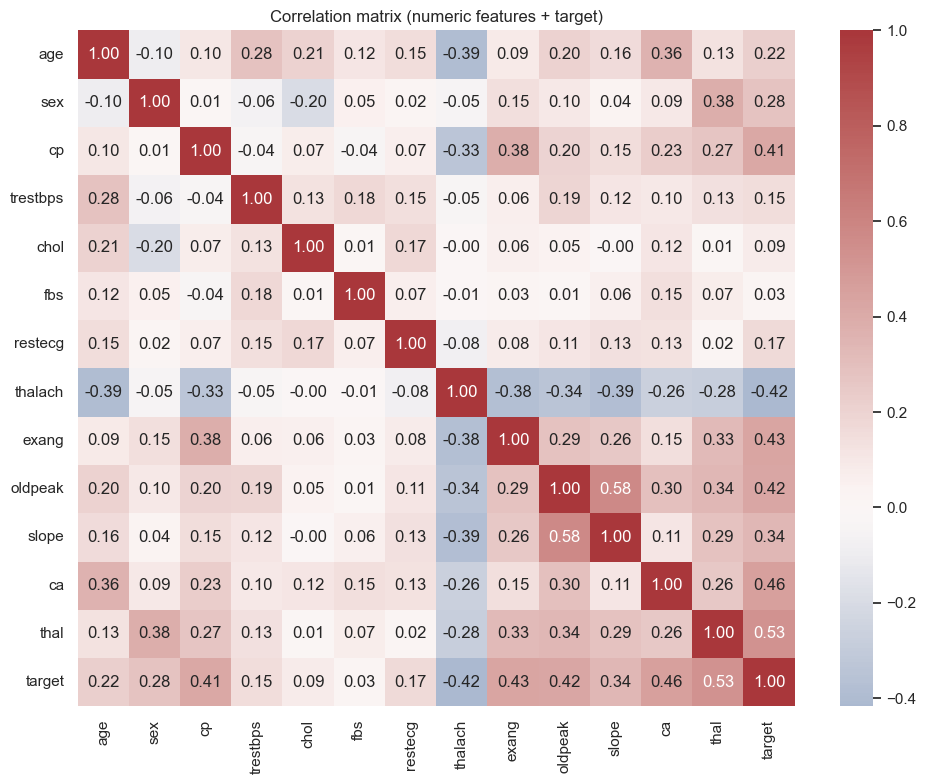

In [5]:
numeric_df = df.drop(columns=["num"]).copy()
numeric_df["target"] = y

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

## Distributions of key attributes by target class

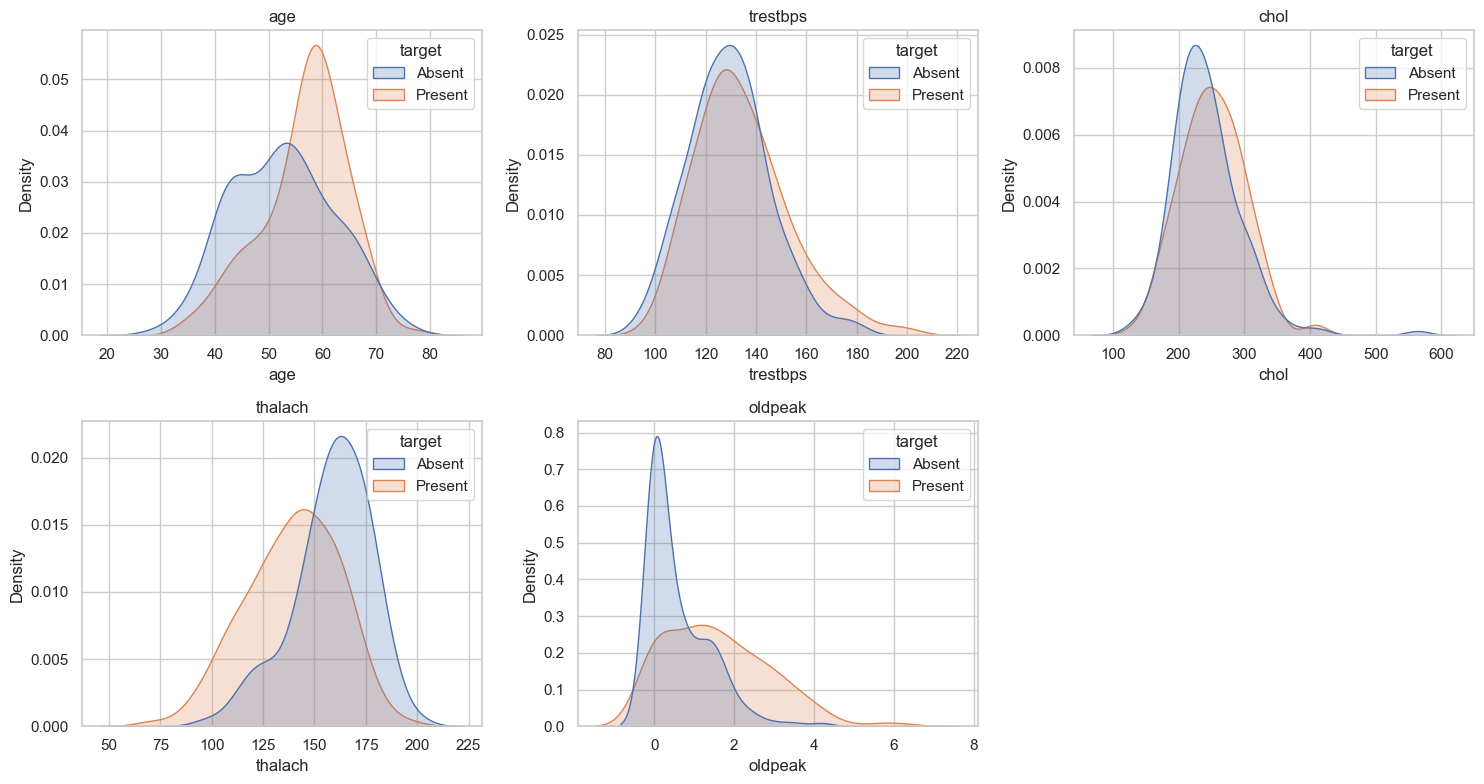

In [6]:
key_attributes = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_df = X.copy()
plot_df["target"] = y.map({0: "Absent", 1: "Present"})

for ax, attr in zip(axes, key_attributes):
    sns.kdeplot(data=plot_df, x=attr, hue="target", fill=True, common_norm=False, ax=ax)
    ax.set_title(attr)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("attribute_distributions.png", dpi=120)
plt.show()

## Chest pain type vs. target

`cp` (chest pain type) is one of the strongest categorical predictors:
asymptomatic patients (cp=4) skew heavily toward disease-present.

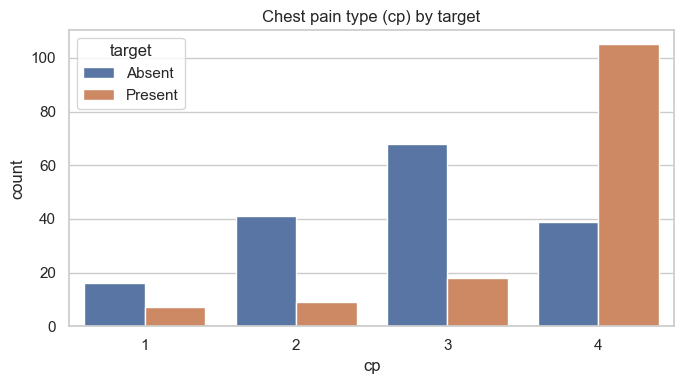

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=plot_df, x="cp", hue="target")
plt.title("Chest pain type (cp) by target")
plt.tight_layout()
plt.savefig("cp_vs_target.png", dpi=120)
plt.show()

## Takeaways

- Classes are moderately imbalanced (~54% absent / ~46% present) —
  stratified splitting and F1/ROC-AUC (not accuracy alone) matter for
  honest evaluation.
- `ca` and `thal` have a handful of missing values that the modeling
  pipeline imputes explicitly.
- `thalach` (max heart rate), `oldpeak` (ST depression), `cp` (chest pain
  type), and `thal` show the clearest separation between classes and show
  up as top features in the trained model's feature importances.